In [1]:
import matplotlib.pyplot as plt 
import numpy as np
import os 
import sys 

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, parent_dir)

from utils.ppnet_utils import initialize_network, custom_se
from utils.gen_utils import load_config
from utils.load_data_utils import load_sampled_input_data

In [2]:
config = load_config('config.yaml')

# initialise the network and use the same data to solve wls and GAT for the SE 
net = initialize_network(net_name=config['data']['net_name'],
                         load_std=config['data']['load_std'])

num_samples = config['data']['num_samples']
num_buses = len(net.bus)

# use same data for all: wls, gat, tapsegnn
sampled_input_data = load_sampled_input_data(sc_type=config['data']['scenario_type'], 
                                                   net=net, 
                                                   num_samples=config['data']['num_samples'], 
                                                   noise=config['data']['noise'])


Transformer Indices for MVO are available from [0,141] 

Number of Trafos = 143 
 
Network: MVO is selected 

Net MVO has 320 nodes and 318 edges. 

Filling nan as 0 in tap_pos, tap_neutral, tap_step_degree
Selecting all the MV/LV transformers in the network 

>>> Using relative noise of 1.0% on voltage and 5.0% on power measurements.
Scaling inputs...
Number of V, P measurements 315 out of 640

Number of P_to, Q_to, P_from, Q_from measurements 163 out of 324

Sparsity of PV measurements at buses = 0.5%
Sparsity of P+ measurements at branches = 0.5


Please ignore sparsity comments here.

In [4]:
import logging
from tqdm import tqdm

# Disable pandapower state estimation debug messages
logging.getLogger('pandapower.estimation.state_estimation').setLevel(logging.WARNING)

# Or disable all pandapower debug messages
logging.getLogger('pandapower').setLevel(logging.WARNING)

# WLS estimates
wls_est_v = np.zeros((num_buses, num_samples))
wls_est_a = np.zeros((num_buses, num_samples))
label_v_pfr = np.zeros((num_buses, num_samples))
label_a_pfr = np.zeros((num_buses, num_samples))

for sample_id in tqdm(range(10)):
    label_v_pfr[:, sample_id] = sampled_input_data['res_bus_vm_pu'][:,sample_id]
    label_a_pfr[:, sample_id] = sampled_input_data['res_bus_va_deg'][:,sample_id]
    
    pfr_dict = {'vm_pfr': sampled_input_data['res_bus_vm_pu'][:,sample_id], 
                'p_pfr': sampled_input_data['res_bus_p_mw'][:,sample_id],
                'p_pfr_line': sampled_input_data['edge_p_pfr_edge'][:,sample_id],
                'q_pfr': sampled_input_data['res_bus_q_mvar'][:,sample_id]}
    
    net_meas = custom_se(net=net, pfr_dict=pfr_dict, se_iter=20) 
                         
    wls_est_v[:, sample_id] = net_meas.res_bus_est.vm_pu.values
    wls_est_a[:, sample_id] = net_meas.res_bus_est.va_degree.values 


  0%|          | 0/10 [00:00<?, ?it/s]WARNING:pandapower.estimation.state_estimation:Estimation failed! Pandapower network failed to update!


State estimation failed. Retrying... Remaining attempts: 19


State estimation failed. Retrying... Remaining attempts: 18


 10%|█         | 1/10 [00:03<00:30,  3.38s/it]WARNING:pandapower.estimation.state_estimation:Estimation failed! Pandapower network failed to update!


State estimation failed. Retrying... Remaining attempts: 19


...

State estimation failed. Retrying... Remaining attempts: 14


State estimation failed. Retrying... Remaining attempts: 13


State estimation failed. Retrying... Remaining attempts: 12


 10%|█         | 1/10 [00:13<01:57, 13.04s/it]


KeyboardInterrupt: 

In [10]:
wls_est_a[:,0].shape

(320,)

In [ ]:
wls_rmse_v = np.sqrt(np.mean((label_v_pfr - wls_est_v)**2, axis=1))
wls_rmse_a = np.sqrt(np.mean((label_a_pfr - wls_est_a)**2, axis=1))
wls_rmse_v, wls_rmse_a

# wls_rmse_v = np.sqrt(np.mean((label_v_pfr - wls_est_v)**2, axis=1))
# wls_rmse_a = np.sqrt(np.mean((label_a_pfr - wls_est_a)**2, axis=1))
# wls_rmse_v, wls_rmse_a


(array([0.04963124, 0.04969295, 0.04973618, 0.04965921, 0.04966943,
        0.05003518, 0.05054044, 0.05003675, 0.04959026, 0.05043165,
        0.04861841, 0.05183099, 0.05066029, 0.04730179, 0.05040456,
        0.04703254, 0.05130638, 0.0487185 , 0.05162004, 0.04986151,
        0.04732697, 0.04732954, 0.04738472, 0.05061147, 0.0496173 ,
        0.04704845, 0.04740717, 0.05106718, 0.04900881, 0.0505492 ,
        0.05038443, 0.04988195, 0.05007231, 0.04966317, 0.05011453,
        0.05037323, 0.04984189, 0.05004519, 0.04916076, 0.05095819,
        0.04917978, 0.04998148, 0.0498475 , 0.05022098, 0.04992871,
        0.05036117, 0.05002719, 0.0503829 , 0.04986298, 0.05040063,
        0.0498646 , 0.04984097, 0.0504099 , 0.04999113, 0.04914266,
        0.05056844, 0.04991249, 0.04997261, 0.05000415, 0.04736153,
        0.04726046, 0.04815479, 0.05218516, 0.05166815, 0.04984037,
        0.04984269, 0.04877529, 0.04794713, 0.05006184, 0.04684613,
        0.0495992 , 0.05065109, 0.05028709, 0.05

In [ ]:
import torch
from utils.model_utils import initialize_model, get_eval_results
from src.dataset.custom_dataset import NodeEdgeTapDatasetV2
from utils.gen_utils import dataset_splitter
from training.trainer import trainer

device='cpu'

dataset = NodeEdgeTapDatasetV2(model_name=config['model']['name'], sampled_input_data=sampled_input_data)

all_loaders, plot_loader = dataset_splitter(dataset,
                                            batch_size=config['loader']['batch_size'],
                                            split_list=config['loader']['split_list'])

# use GAT 
model_GAT = initialize_model(model_name="GATRegressor",
                            dataset=dataset,
                            node_out_features=config['model']['node_out_features'],
                            list_node_hidden_features=config['model']['list_node_hidden_features'],
                            k_hop_node=config['model']['k_hop_node'],
                            edge_out_features=config['model']['edge_out_features'], 
                            list_edge_hidden_features=config['model']['list_edge_hidden_features'],
                            k_hop_edge=config['model']['k_hop_edge'],
                            trafo_hop=config['model']['trafo_hop'],
                            edge_index_list=sampled_input_data['edge_index'],
                            gat_out_features=config['model']['gat_out_features'],
                            gat_head=config['model']['gat_head'],
                            bias=config['model']['bias'], 
                            normalize=config['model']['normalize'], 
                            device=device,  
                            ).to(device)    

total_params = sum(p.numel() for p in model_GAT.parameters() if p.requires_grad)

print(f'Total number of parameters of model {model_GAT}: {total_params}')

optimizer_GAT = torch.optim.Adam(model_GAT.parameters(),lr=config['training']['lr'], weight_decay=config['training']['weight_decay'])

schedular_GAT = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer_GAT, 
                                                    mode='min',
                                                    factor=0.1, 
                                                    # patience=1,
                                                    min_lr=config['training']['schedular_min_lr'])

# GAT 
all_losses_GAT = trainer(model=model_GAT, 
                    train_loader=all_loaders[0], 
                    val_loader=all_loaders[1], 
                    test_loader=all_loaders[2], 
                    optimizer=optimizer_GAT,
                    schedular=schedular_GAT,
                    num_epoch=200,
                    early_stopping=config['training']['early_stopping'],
                    val_patience=config['training']['val_patience'],  
                    device=device)

results, pred_se_va, label_se_va = get_eval_results(test_loader=all_loaders[2],
                                tap_weight=config['training']['loss_tap_weight'], 
                                trained_model=model_GAT, 
                                scaler=sampled_input_data['scaler_y_label'], 
                                output_pred_va=True)

Dataset for MultiTapSEGNN selected!


 Directed power flows accounted in dataset...


 get_edge_index_lu handling dictionary of tensors...

Total number of parameters of model GATRegressor(
  (gatconv): GATConv(2, 32, heads=1)
  (mlp_gat): Sequential(
    (0): Linear(in_features=32, out_features=2, bias=True)
  )
): 450
At epoch: 0, 	 training loss: 5.731e-01,                     	 validation loss: 4.221e-01 	 lr: 1.00e-02 	 grad_norm: 6.289e-01
At epoch: 25, 	 training loss: 3.267e-01,                     	 validation loss: 3.260e-01 	 lr: 1.00e-02 	 grad_norm: 1.645e-01
At epoch: 50, 	 training loss: 3.255e-01,                     	 validation loss: 3.251e-01 	 lr: 1.00e-04 	 grad_norm: 3.158e-02
At epoch: 75, 	 training loss: 3.255e-01,                     	 validation loss: 3.251e-01 	 lr: 1.00e-04 	 grad_norm: 6.780e-02
At epoch: 100, 	 training loss: 3.256e-01,                     	 validation loss: 3.251e-01 	 lr: 1.00e-04 	 grad_norm: 4.981e-02
At epoch: 125, 	 training loss: 3

In [ ]:
num_graphs = int(pred_se_va.shape[0]/num_buses)

# remove offset 
pred_se_va = pred_se_va - 10.0
label_se_va = label_se_va - 10.0 

pred_se_va_rs = torch.reshape(pred_se_va, (num_graphs,num_buses,-1))
label_se_va_rs = torch.reshape(label_se_va, (num_graphs,num_buses,-1))

error_pl = (pred_se_va_rs - label_se_va_rs)
error_v = error_pl[:,:,0].T 
error_a = error_pl[:,:,1].T

error_v = error_v ** 2
error_a = error_a ** 2 

mean_error_v = error_v.mean(dim=1)
gat_rmse_v = torch.sqrt(mean_error_v)

mean_error_a = error_a.mean(dim=1)
gat_rmse_a = torch.sqrt(mean_error_a)

In [ ]:
# use TapSEGNN 
model = initialize_model(model_name="NEGATRegressor",
                        dataset=dataset,
                        node_out_features=config['model']['node_out_features'],
                        list_node_hidden_features=config['model']['list_node_hidden_features'],
                        k_hop_node=config['model']['k_hop_node'],
                        edge_out_features=config['model']['edge_out_features'], 
                        list_edge_hidden_features=config['model']['list_edge_hidden_features'],
                        k_hop_edge=config['model']['k_hop_edge'],
                        trafo_hop=config['model']['trafo_hop'],
                        edge_index_list=sampled_input_data['edge_index'],
                        gat_out_features=config['model']['gat_out_features'],
                        gat_head=config['model']['gat_head'],
                        bias=config['model']['bias'], 
                        normalize=config['model']['normalize'], 
                        device=device,
                        ).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total number of parameters of model {model}: {total_params}')

optimizer = torch.optim.Adam(model.parameters(),
                            lr=config['training']['lr'], 
                            weight_decay=config['training']['weight_decay'])
        
schedular = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, 
                                                    mode='min',
                                                    factor=0.1, 
                                                    patience=1,
                                                    min_lr=config['training']['schedular_min_lr'])

all_losses = trainer(model=model, 
                    train_loader=all_loaders[0], 
                    val_loader=all_loaders[1], 
                    test_loader=all_loaders[2], 
                    optimizer=optimizer,
                    schedular=schedular,
                    num_epoch=config['training']['num_epochs'],
                    early_stopping=config['training']['early_stopping'],
                    val_patience=config['training']['val_patience'], 
                    tap_weight=config['training']['loss_tap_weight'], 
                    device=device)

results_tapse, pred_se_va_tapse, label_se_va_tapse  = get_eval_results(test_loader=all_loaders[2],
                                tap_weight=config['training']['loss_tap_weight'], 
                            trained_model=model, 
                            scaler=sampled_input_data['scaler_y_label'], 
                            output_pred_va=True)

Total number of parameters of model NEGATRegressor(
  (node_layers): ModuleList(
    (0): TAGConv(2, 64, K=3)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (fc_node): Linear(in_features=64, out_features=32, bias=True)
  (edge_layers): ModuleList(
    (0): ModuleList(
      (0-1): 2 x TAGConv(6, 128, K=1)
    )
  )
  (edge_biases): ParameterList(  (0): Parameter containing: [torch.float32 of size 128])
  (fc_edge): Linear(in_features=128, out_features=64, bias=True)
  (gatconv): GATConv(32, 32, heads=1)
  (mlp_gat): Sequential(
    (0): Linear(in_features=32, out_features=2, bias=True)
  )
): 17506
At epoch: 0, 	 training loss: 1.538e+00,                     	 validation loss: 4.304e-01 	 lr: 1.00e-02 	 grad_norm: 1.124e+01
At epoch: 25, 	 training loss: 1.629e-01,                     	 validation loss: 1.619e-01 	 lr: 1.00e-04 	 grad_norm: 6.364e-01
At epoch: 50, 	 training loss: 1.561e-01,                     	 validation loss: 1.550e-01 	 lr: 1.00e-04 	 grad_nor

In [ ]:
# remove offset 
pred_se_va = pred_se_va_tapse - 10.0 
label_se_va = label_se_va_tapse - 10.0 

pred_se_va_rs = torch.reshape(pred_se_va, (num_graphs,num_buses,-1))
label_se_va_rs = torch.reshape(label_se_va, (num_graphs,num_buses,-1))

# Calculate errors for voltage (index 0) and angle (index 1) 
error_v = pred_se_va_rs[:, :, 0] - label_se_va_rs[:, :, 0]  # Shape: (batch_size, num_buses)
error_a = pred_se_va_rs[:, :, 1] - label_se_va_rs[:, :, 1]  # Shape: (batch_size, num_buses)

error_v = error_v ** 2
error_a = error_a ** 2 

mean_error_v = error_v.mean(dim=0)
tapsegnn_rmse_v = torch.sqrt(mean_error_v)

mean_error_a = error_a.mean(dim=0)
tapsegnn_rmse_a = torch.sqrt(mean_error_a)

DEBUG:matplotlib.pyplot:Loaded backend inline version unknown.


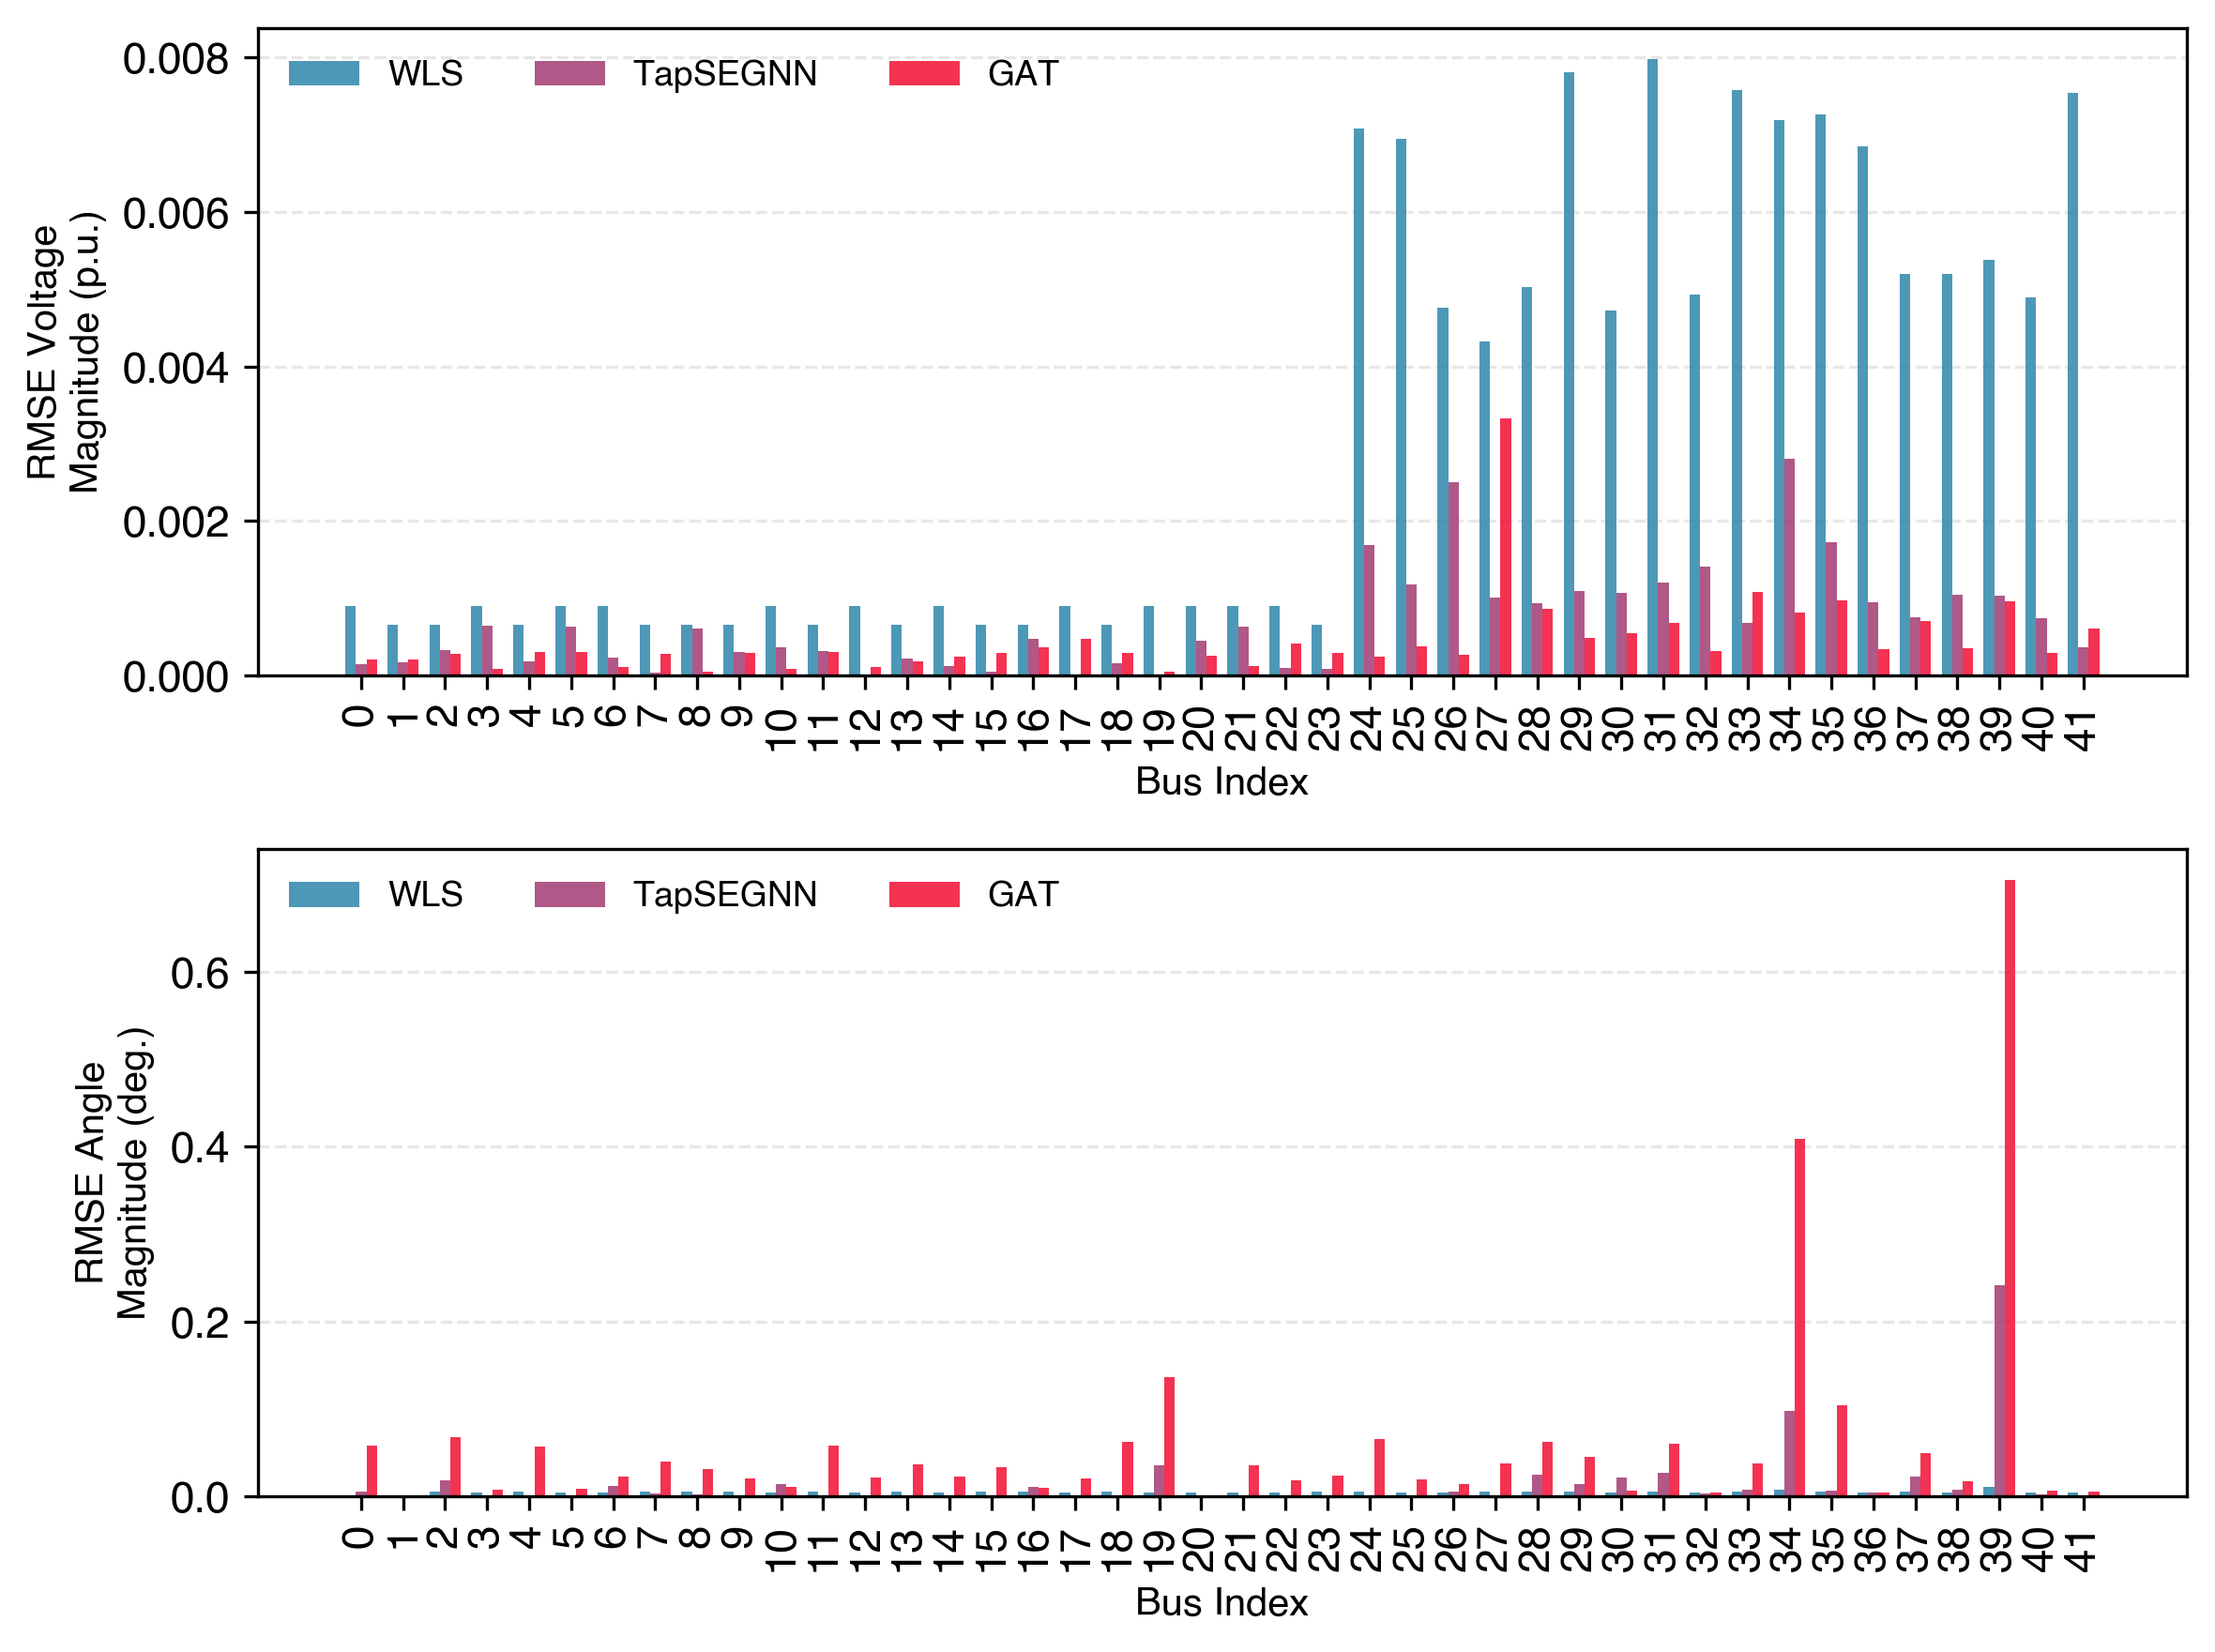

In [ ]:
%matplotlib inline
# Set publication-quality style with modern fonts
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Proxima Nova', 'Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'semibold'

# Create figure with two subplots
fig, ax = plt.subplots(2, 1, figsize=(8, 6))
x = np.arange(len(net.bus))
width = 0.25

# Plot bus-specific voltage RMSE
bars1 = ax[0].bar(x - width, wls_rmse_v, width, label='WLS',
                  color='#2E86AB', alpha=0.85, edgecolor='none')
bars2 = ax[0].bar(x, tapsegnn_rmse_v, width, label='TapSEGNN',
                  color='#A23B72', alpha=0.85, edgecolor='none')
bars3 = ax[0].bar(x + width, gat_rmse_v, width, label='GAT',
                  color='#F30E34', alpha=0.85, edgecolor='none')

ax[0].set_xlabel('Bus Index', fontweight='semibold', fontsize=10)
ax[0].set_ylabel('RMSE Voltage\nMagnitude (p.u.)', fontweight='semibold', fontsize=10)
ax[0].legend(loc='upper left', ncol=3, frameon=False, fontsize=9)
ax[0].grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0)
ax[0].set_axisbelow(True)
ax[0].set_xticks(x)
ax[0].set_xticklabels(x, rotation=90)

# Plot bus-specific angle RMSE
bars1a = ax[1].bar(x - width, wls_rmse_a, width, label='WLS',
                   color='#2E86AB', alpha=0.85, edgecolor='none')
bars2a = ax[1].bar(x, tapsegnn_rmse_a, width, label='TapSEGNN',
                   color='#A23B72', alpha=0.85, edgecolor='none')
bars3a = ax[1].bar(x + width, gat_rmse_a, width, label='GAT',
                   color='#F30E34', alpha=0.85, edgecolor='none')

ax[1].set_xlabel('Bus Index', fontweight='semibold', fontsize=10)
ax[1].set_ylabel('RMSE Angle\nMagnitude (deg.)', fontweight='semibold', fontsize=10)
ax[1].legend(loc='upper left', ncol=3, frameon=False, fontsize=9)
ax[1].grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0)
ax[1].set_axisbelow(True)
ax[1].set_xticks(x)
ax[1].set_xticklabels(x, rotation=90)

plt.tight_layout()
plt.show()

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 3))

# x = np.arange(len(net.bus))

# # plot bus-specific voltage RMSE 
# width = 0.6

# bars1 = ax[0].bar(x - width/3, wls_rmse_v, width, label='WLS', 
#                 color='#2E86AB', alpha=0.85, edgecolor='none')
# bars2 = ax[0].bar(x, tapsegnn_rmse_v, width, label='TapSEGNN',
#                 color='#A23B72', alpha=0.85, edgecolor='none')
# bars3 = ax[0].bar(x + width/3, gat_rmse_v, width, label='GAT', 
#                 color="#F30E34")

# ax[0].set_xlabel('Bus Index', fontweight='semibold')
# ax[0].set_ylabel('RMSE Voltage \n Magnitude (p.u.)', fontweight='semibold')
# # ax[0].set_title('Variable V: RMSE Comparison', fontweight='semibold')
# plt.legend(
#     loc='lower center',     # place legend above the plot
#     bbox_to_anchor=(0.5, 0.85),  # center it horizontally, push slightly above
#     ncol=3,                 # number of columns (adjust depending on how many labels you have)
#     frameon=False           # optional: remove legend box frame
# )
# ax[0].grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0)
# ax[0].set_axisbelow(True)


# # plot bus-specific angle RMSE 
# width = 0.6

# bars1a = ax[1].bar(x - width/3, wls_rmse_a, width, label='WLS', 
#                 color='#2E86AB', alpha=0.85, edgecolor='none')
# bars2a = ax[1].bar(x, tapsegnn_rmse_a, width, label='TapSEGNN',
#                 color='#A23B72', alpha=0.85, edgecolor='none')
# bars3a = ax[1].bar(x + width/3, gat_rmse_a, width, label='GAT', 
#                 color="#F30E34")

# ax[1].set_xlabel('Bus Index', fontweight='semibold')
# ax[1].set_ylabel('RMSE Angle \n Magnitude (deg.)', fontweight='semibold')
# plt.legend(
#     loc='lower center',     # place legend above the plot
#     bbox_to_anchor=(0.5, 0.85),  # center it horizontally, push slightly above
#     ncol=3,                 # number of columns (adjust depending on how many labels you have)
#     frameon=False           # optional: remove legend box frame
# )
# ax[1].grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0)
# ax[1].set_axisbelow(True)


In [ ]:
tapsegnn_rmse_v

tensor([1.4506e-04, 1.7159e-04, 3.3104e-04, 6.4066e-04, 1.8451e-04, 6.3126e-04,
        2.2350e-04, 2.8349e-05, 6.0760e-04, 2.9928e-04, 3.6416e-04, 3.1540e-04,
        6.3808e-06, 2.1691e-04, 1.2254e-04, 4.8259e-05, 4.7623e-04, 5.4459e-06,
        1.5147e-04, 1.0737e-05, 4.4553e-04, 6.2867e-04, 9.5486e-05, 8.6904e-05,
        1.6904e-03, 1.1774e-03, 2.4990e-03, 1.0094e-03, 9.2740e-04, 1.0880e-03,
        1.0677e-03, 1.1945e-03, 1.4019e-03, 6.7366e-04, 2.8079e-03, 1.7252e-03,
        9.4158e-04, 7.5595e-04, 1.0378e-03, 1.0318e-03, 7.3513e-04, 3.5805e-04])

In [ ]:
wls_sum_v = np.sum(wls_rmse_v)
tapsegnn_sum_rmse_v = torch.sum(tapsegnn_rmse_v)
gat_sum_rmse_v = torch.sum(gat_rmse_v)

wls_sum_a = np.sum(wls_rmse_a)
tapsegnn_sum_rmse_a = torch.sum(tapsegnn_rmse_a)
gat_sum_rmse_a = torch.sum(gat_rmse_a)

wls_sum_v, tapsegnn_sum_rmse_v, gat_sum_rmse_v, wls_sum_a, tapsegnn_sum_rmse_a, gat_sum_rmse_a

(np.float64(0.1293060674971169),
 tensor(0.0284),
 tensor(0.0187),
 np.float64(0.20107637529734584),
 tensor(0.6020),
 tensor(2.4575))

In [ ]:
fig.savefig('FIG_baselines.pdf', dpi=300, bbox_inches='tight')

DEBUG:matplotlib.backends.backend_pdf:Assigning font /F1 = '/System/Library/Fonts/Helvetica.ttc'
DEBUG:matplotlib.backends.backend_pdf:Embedding font /System/Library/Fonts/Helvetica.ttc.
DEBUG:matplotlib.backends.backend_pdf:Writing TrueType font.


In [ ]:
torch.save(model_GAT.state_dict(), parent_dir + "/results/best_GAT.pth")
torch.save(model.state_dict(), parent_dir + "/results/best_NEGATRegressor.pth")
